# Линейная регрессия: Практическое Задание

## Цель:
В этом задании вы будете работать с линейной регрессией на наборе данных "Wine Quality". Вы загрузите данные, изучите их, примените регуляризацию и проанализируете метрики модели.

Главное – понять как работают модели

## А что конкретно будем делать:

1. Загрузите датасет в формате CSV.
2. Изучите структуру и содержание данных.
3. Примените разные подходы к регуляризации.
4. Выведите метрики модели и проинтерпретируйте их.
5. Сделайте выводы об объясняющей способности модели и переменных в частности.

## Дальше всё пошагово прописано – удачи!)


## Шаг 0: Установка и импорт библиотек

In [27]:
# ## Установка библиотек
# !pip install scikit-learn -q
# !pip install statsmodels==0.14.3 -q
# !pip install seaborn -q

In [28]:
import statsmodels

print(statsmodels.__version__)

0.14.5


In [29]:
## Импорт библиотек
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

## Шаг 1: Загрузка данных

In [30]:
# Загрузка датасета Wine Quality
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
data = pd.read_csv(url, sep=';')

# Просмотр первых нескольких строк датасета
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [31]:
# Описание датафрейма
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [32]:
# Статистические характеристики
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [33]:
# Проверка на пропущенные значения
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

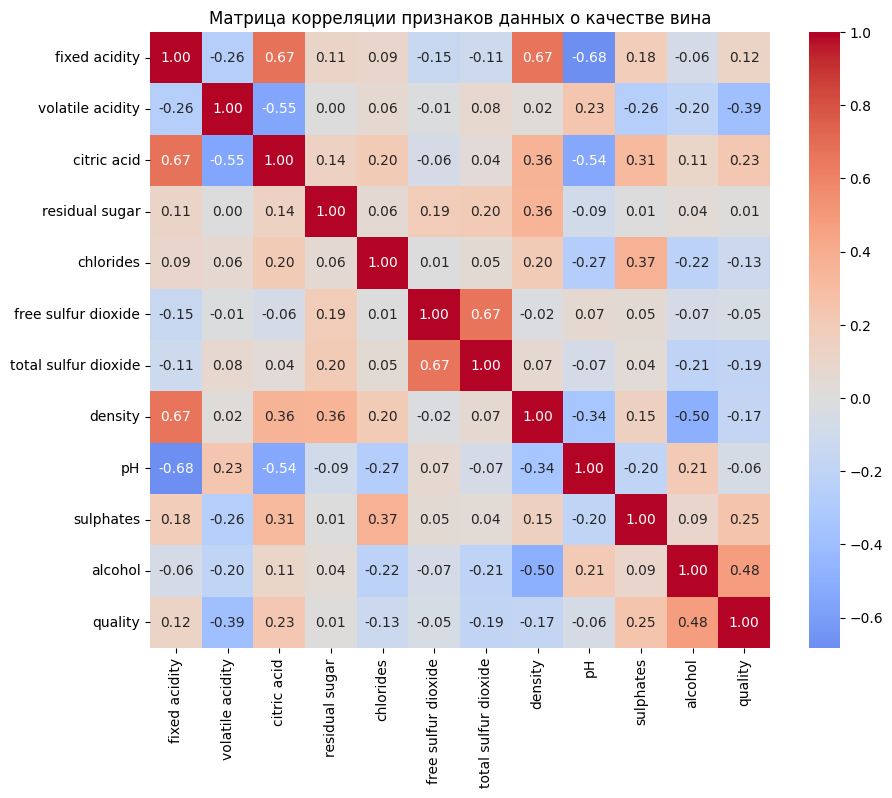

In [34]:
# Построение матрицы корреляции
correlation_matrix = data.corr()

# Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков данных о качестве вина')
plt.show()

#### Напишите ниже в параграфе несколько признаков, наиболее скореллированных с объясняемой переменной переменной **quality**

Признаки:
- признак 1
- ...
  

#### Можем ли мы далее столкнуться с мультиколлинеарностью признаков? Если да, то перечислите несколько переменных, которые могут на это указывать

Да / Нет

Признаки:
- признак 1 и признак 2
- ...

## Шаг 2 – построение модели

In [35]:
# Определение признаков и целевой переменной
y = data['quality']  # Целевая переменная
X = data.drop('quality', axis=1)  # Признаки

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Добавление константы
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Линейная регрессия
model_ols = sm.OLS(y_train, X_train_sm).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     61.48
Date:                Tue, 25 Nov 2025   Prob (F-statistic):          1.48e-109
Time:                        16:17:14   Log-Likelihood:                -1266.4
No. Observations:                1279   AIC:                             2557.
Df Residuals:                    1267   BIC:                             2619.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   14.3551 

#### Какие признаки оказалист незначимыми для нашей модели? Обратите внимание на показатель P>|t|

Признаки:
- признак 1
- ...
  
  

## Шаг 3 – регуляризация

In [37]:
# Модель с Lasso-регуляризацией
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Модель с Ridge-регуляризацией
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Вывод метрик для Lasso
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso MSE: {mse_lasso:.4f}, R²: {r2_lasso:.4f}")

# Вывод метрик для Ridge
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge MSE: {mse_ridge:.4f}, R²: {r2_ridge:.4f}")

Lasso MSE: 0.6476, R²: 0.0090
Ridge MSE: 0.3929, R²: 0.3987


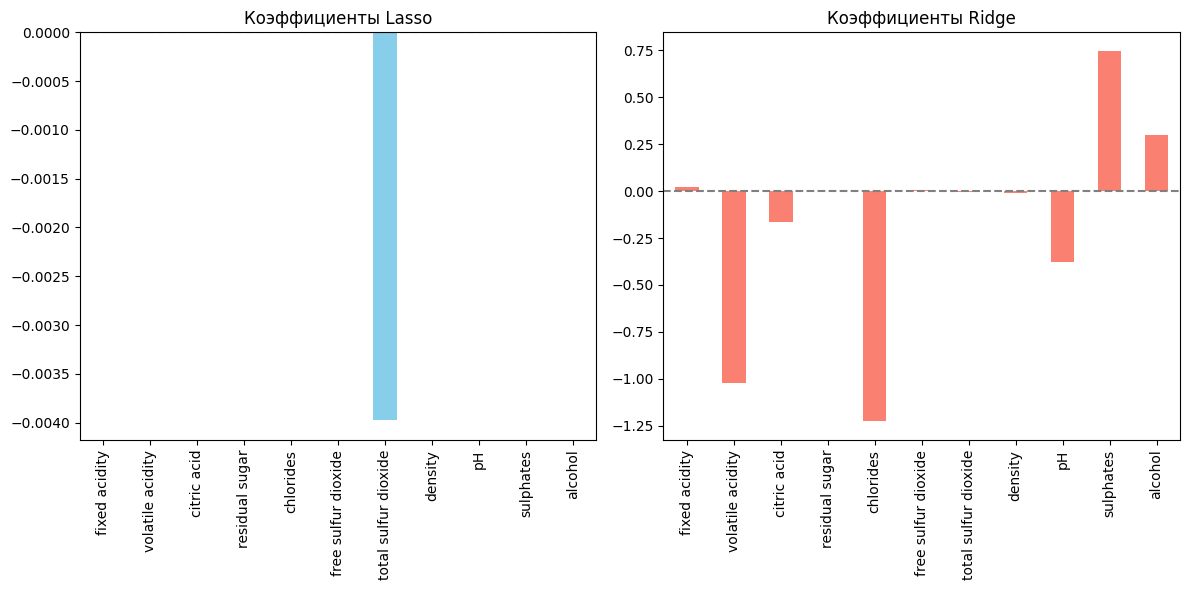

In [38]:
# Вывод коэффициентов Lasso
lasso_coef = pd.Series(lasso.coef_, index=X.columns)

# Вывод коэффициентов Ridge
ridge_coef = pd.Series(ridge.coef_, index=X.columns)

# Визуализация коэффициентов
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
lasso_coef.plot(kind='bar', title='Коэффициенты Lasso', color='skyblue')
plt.axhline(0, linestyle='--', color='gray')

plt.subplot(1, 2, 2)
ridge_coef.plot(kind='bar', title='Коэффициенты Ridge', color='salmon')
plt.axhline(0, linestyle='--', color='gray')

plt.tight_layout()
plt.show()

## Шаг 4 – выводы по моделям и интерпретация

#### Выше мы построили Lasso и Ridge модели, давайте попробуем ответить на несколько вопросов:

1) Сравните метрики моделей, как их можно проинтерпретировать?

2) Почему обнулились некоторые метрики? Почему Lasso обнулила больше, чем Ridge?

3) Посмотрите коэффициенты моделей, сделайте выводы о том, как каждая из них влияет на объясняемую переменную

1) ответ

2) ответ

3) ответ